# 01_Cleaning — UK Used Car Listings

Raw source: `../data/raw/used_cars.csv` (99,187 rows as scraped — model, year, price,
transmission, mileage, fuelType, tax, mpg, engineSize, Make).

This notebook has two parts:

- **Part 0** builds a supplementary Make/Model reference table from the NHTSA vPIC API.
  It is *not* merged into the main cleaning pipeline below — kept here as prep for a future
  standardization step, not a dependency of anything that follows.
- **Part 1 onward** is the actual cleaning pipeline: structural fixes → engineSize repair →
  year sanity checks → mpg cleaning → target transform → save.

**One structural fix from the previous version of this notebook:** the cleaned CSV used to get
saved to disk *before* the mpg outlier investigation at the end ran — meaning the BMW i3
placeholder values found later never actually made it out of the saved file. The save step now
happens once, at the very end, after every cleaning decision.


## Part 0 — Reference data: NHTSA vPIC Make/Model lookup

Makes a handful of live API calls (needs internet, ~5–10s). Not required for the cleaning pipeline below.

In [1]:
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

RAW_DIR = Path("../data/raw")
RAW_DIR.mkdir(parents=True, exist_ok=True)

VPIC_BASE = "https://vpic.nhtsa.dot.gov/api/vehicles"


In [2]:
df_cars = pd.read_csv(RAW_DIR / "used_cars.csv")

print("Shape:", df_cars.shape)
df_cars.head()


Shape: (99187, 11)


,Unnamed: 0,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,0,T-Roc,2019,25000,Automatic,13904,Diesel,145,49.6,2.0,VW
1,1,T-Roc,2019,26883,Automatic,4562,Diesel,145,49.6,2.0,VW
2,2,T-Roc,2019,20000,Manual,7414,Diesel,145,50.4,2.0,VW
3,3,T-Roc,2019,33492,Automatic,4825,Petrol,145,32.5,2.0,VW
4,4,T-Roc,2019,22900,Semi-Auto,6500,Petrol,150,39.8,1.5,VW


In [3]:
def get_all_makes() -> pd.DataFrame:
    """Fetch the full list of vehicle Makes recognized by NHTSA vPIC."""
    url = f"{VPIC_BASE}/GetAllMakes?format=json"
    resp = requests.get(url, timeout=15)
    resp.raise_for_status()
    results = resp.json()["Results"]
    return pd.DataFrame(results)

df_all_makes = get_all_makes()
print(df_all_makes.shape)
df_all_makes.head()


(12361, 2)


,Make_ID,Make_Name
0,12858,#1 ALPINE CUSTOMS
1,4877,"1/OFF KUSTOMS, LLC"
2,11257,"102 IRONWORKS, INC."
3,12255,12832429 CANADA INC.
4,13053,137 INDUSTRIES INC.


In [4]:
df_all_makes.to_csv(RAW_DIR / "vpic_all_makes.csv", index=False)
print("Saved:", RAW_DIR / "vpic_all_makes.csv")


Saved: ..\data\raw\vpic_all_makes.csv


In [5]:
# Raw `Make` values in this dataset use inconsistent casing/abbreviations
# (e.g. 'VW', 'vauxhall', 'merc', 'hyundi') rather than the official vPIC names.
# This map only covers the makes present in *this* dataset — extend it if you
# bring in more brands later, since anything missing here silently becomes NaN.
MAKE_MAP = {
    "VW": "Volkswagen", "vauxhall": "Vauxhall", "merc": "Mercedes-Benz",
    "hyundi": "Hyundai", "ford": "Ford", "toyota": "Toyota",
    "skoda": "Skoda", "BMW": "BMW", "Audi": "Audi",
}
df_cars["Make_clean"] = df_cars["Make"].map(MAKE_MAP)

unmapped = df_cars[df_cars["Make_clean"].isna()]["Make"].unique()
if len(unmapped):
    print("Warning — raw Make values with no entry in MAKE_MAP:", unmapped)

def get_models_for_make(make_name: str) -> pd.DataFrame:
    """Fetch all Models vPIC has on record for a given Make."""
    url = f"{VPIC_BASE}/GetModelsForMake/{make_name}?format=json"
    resp = requests.get(url, timeout=15)
    resp.raise_for_status()
    results = resp.json()["Results"]
    out = pd.DataFrame(results)
    out["queried_make"] = make_name
    return out

our_makes = sorted(df_cars["Make_clean"].dropna().unique())
print("Fetching models for:", our_makes)

model_frames = []
for make_name in our_makes:
    frame = get_models_for_make(make_name)
    print(f"  {make_name}: {len(frame)} models returned")
    model_frames.append(frame)
    time.sleep(0.5)  # be a polite API citizen

df_models = pd.concat(model_frames, ignore_index=True)
print("Total rows:", df_models.shape)


Fetching models for: ['Audi', 'BMW', 'Ford', 'Hyundai', 'Mercedes-Benz', 'Skoda', 'Toyota', 'Vauxhall', 'Volkswagen']
  Audi: 57 models returned
  BMW: 260 models returned
  Ford: 168 models returned
  Hyundai: 40 models returned
  Mercedes-Benz: 62 models returned
  Skoda: 0 models returned
  Toyota: 58 models returned
  Vauxhall: 0 models returned
  Volkswagen: 40 models returned
Total rows: (685, 5)


In [6]:
df_models.to_csv(RAW_DIR / "vpic_models_by_make.csv", index=False)
print("Saved:", RAW_DIR / "vpic_models_by_make.csv")


Saved: ..\data\raw\vpic_models_by_make.csv


**Status: reference data only, not yet used.** Skoda and Vauxhall returned 0 models from
vPIC (likely a naming mismatch between our brand string and vPIC's expected format — worth
checking against `vpic_all_makes.csv` before relying on this table). `df_cars` and `df_models`
aren't referenced again below; the cleaning pipeline starts fresh with its own read of the raw
CSV in Part 1.

## Part 1 — Load & initial inspection

Fresh read into `df` — this is the dataframe the rest of the notebook builds on.

In [7]:
df = pd.read_csv(RAW_DIR / "used_cars.csv")
df.head(10)


,Unnamed: 0,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,0,T-Roc,2019,25000,Automatic,13904,Diesel,145,49.6,2.0,VW
1,1,T-Roc,2019,26883,Automatic,4562,Diesel,145,49.6,2.0,VW
2,2,T-Roc,2019,20000,Manual,7414,Diesel,145,50.4,2.0,VW
3,3,T-Roc,2019,33492,Automatic,4825,Petrol,145,32.5,2.0,VW
4,4,T-Roc,2019,22900,Semi-Auto,6500,Petrol,150,39.8,1.5,VW
5,5,T-Roc,2020,31895,Manual,10,Petrol,145,42.2,1.5,VW
6,6,T-Roc,2020,27895,Manual,10,Petrol,145,42.2,1.5,VW
7,7,T-Roc,2020,39495,Semi-Auto,10,Petrol,145,32.5,2.0,VW
8,8,T-Roc,2019,21995,Manual,10,Petrol,145,44.1,1.0,VW
9,9,T-Roc,2019,23285,Manual,10,Petrol,145,42.2,1.5,VW


In [8]:
print("Shape:", df.shape)
df.info()


Shape: (99187, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99187 entries, 0 to 99186
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    99187 non-null  int64  
 1   model         99187 non-null  object 
 2   year          99187 non-null  int64  
 3   price         99187 non-null  int64  
 4   transmission  99187 non-null  object 
 5   mileage       99187 non-null  int64  
 6   fuelType      99187 non-null  object 
 7   tax           99187 non-null  int64  
 8   mpg           99187 non-null  float64
 9   engineSize    99187 non-null  float64
 10  Make          99187 non-null  object 
dtypes: float64(2), int64(5), object(4)
memory usage: 8.3+ MB


In [9]:
df.isnull().sum() / len(df) * 100


Unnamed: 0      0.0
model           0.0
year            0.0
price           0.0
transmission    0.0
mileage         0.0
fuelType        0.0
tax             0.0
mpg             0.0
engineSize      0.0
Make            0.0
dtype: float64

**Insight:** zero missing values across every column — this is clean source data. The only nulls we'll create ourselves are the deliberate `engineSize == 0 → NaN` conversion in Part 2, which then gets imputed.

In [10]:
df.duplicated().sum()


np.int64(0)

**Insight — this result is misleading.** `Unnamed: 0` is a per-row index column, so every
row is technically "unique" as long as it's included — `duplicated()` returns 0 here for the
wrong reason. Dropping it below re-runs the check on actual content.

In [11]:
df = df.drop(columns=['Unnamed: 0'])
df.duplicated().sum()


np.int64(1475)

**Insight:** with the index column gone, 1,475 rows (≈1.5% of the dataset) turn out to be exact content duplicates — same model, year, price, mileage, everything. These get dropped below.

In [12]:
df = df.drop_duplicates()
df.shape


(97712, 10)

In [13]:
df['model'] = df['model'].str.strip()


In [42]:
df['Make'] = df['Make'].map(MAKE_MAP)

## Part 2 — Fixing `engineSize == 0`

A real engine can't have zero displacement, so `0` here almost certainly means "not recorded"
rather than a genuine reading — except possibly for Electric vehicles, which don't have a
traditional displacement figure at all.

In [14]:
df[df['engineSize'] == 0]['fuelType'].value_counts()


fuelType
Petrol      158
Diesel       69
Hybrid       38
Electric      2
Other         1
Name: count, dtype: int64

In [15]:
df[df['engineSize'] == 0][
    ['model', 'year', 'price', 'fuelType', 'engineSize', 'Make']
].head(20)


,model,year,price,fuelType,engineSize,Make
649,T-Roc,2019,22000,Petrol,0.0,VW
664,T-Roc,2018,23000,Diesel,0.0,VW
4734,Golf,2015,11800,Diesel,0.0,VW
4761,Golf,2019,18000,Petrol,0.0,VW
4768,Golf,2017,12600,Diesel,0.0,VW
6347,Passat,2018,17000,Petrol,0.0,VW
6351,Passat,2017,16000,Diesel,0.0,VW
6354,Passat,2018,19500,Petrol,0.0,VW
6356,Passat,2019,18500,Petrol,0.0,VW
11559,Tiguan,2017,19200,Diesel,0.0,VW


In [16]:
df[df['engineSize'] > 0]['fuelType'].value_counts()


fuelType
Petrol      53824
Diesel      40350
Hybrid       3021
Other         245
Electric        4
Name: count, dtype: int64

**Insight:** 268 rows have `engineSize == 0`, and all but 2 of them are Petrol, Diesel, or
Hybrid — vehicle types that always have a real displacement figure, so these 266 are clearly
missing data, not genuine zeros. The 2 Electric rows are more ambiguous (EVs legitimately have
no combustion displacement), but they're too small a group to special-case here — they'll go
through the same Make+model median imputation as everything else below. If EV-specific handling
matters for your use case later, this is the spot to revisit.

The fix: treat `0` as missing, then impute using the median `engineSize` for that specific
Make+model combination (a Golf's typical engine size is a better estimate than the fleet-wide
median), falling back to the global median for any Make+model group with no other data to
borrow from.

In [17]:
df['engineSize'] = df['engineSize'].replace(0, np.nan)
df['engineSize'] = df.groupby(['Make', 'model'])['engineSize'].transform(
    lambda x: x.fillna(x.median())
)
df['engineSize'] = df['engineSize'].fillna(df['engineSize'].median())

df['engineSize'].isnull().sum()


np.int64(0)

## Part 3 — Year sanity check & age feature

In [18]:
df[df['year'] > 2026][['model', 'Make', 'year', 'price']]


,model,Make,year,price
77499,Fiesta,ford,2060,6495


In [19]:
df[df['year'] < 1990][['model', 'Make', 'year', 'price']]


,model,Make,year,price
25994,Zafira,vauxhall,1970,10495
53866,M Class,merc,1970,24999


**Insight:** 3 rows are obviously bad data — a Ford Fiesta listed as year **2060** (an
impossible future year for a used-car listing), and a Vauxhall Zafira and Mercedes M-Class both
listed as **1970** (neither model existed yet — the Zafira launched in 1999, the M-Class in
1997). `1970` showing up as a specific wrong value is a common placeholder pattern in scraped
data (it's the Unix epoch year), which is a useful thing to recognize elsewhere in this dataset
too. The `1990–2026` filter below exists specifically to catch these — it's not an arbitrary
business rule.

In [20]:
df = df[(df['year'] >= 1990) & (df['year'] <= 2026)].copy()
df.shape


(97709, 10)

In [21]:
CURRENT_YEAR = 2026
df['age'] = CURRENT_YEAR - df['year']


**Caveat worth confirming:** after the filter above, the newest listing in this dataset is
model year **2020** — there's nothing from 2021–2026. That suggests the data was actually
collected around 2020, not 2026. Using `CURRENT_YEAR = 2026` (today's real date) means every
`age` value is ~5–6 years larger than "years since this car was listed" would be — it's really
computing "years since 2026," not "the car's age at the time it was for sale." If downstream
analysis assumes `age` reflects the vehicle's age *when listed* (e.g. depreciation curves), this
will systematically shift them. If `age` is meant to be pure "age as of today," 2026 is correct
as-is. Worth deciding explicitly rather than leaving it implicit.

In [22]:
df.describe()


,year,price,mileage,tax,mpg,engineSize,age
count,97709.000000,97709.000000,97709.000000,97709.000000,97709.000000,97709.000000,97709.000000
mean,2017.067394,16773.572823,23219.101884,120.138831,55.206047,1.668844,8.932606
std,2.107849,9868.593414,21060.893971,63.354366,16.181724,0.552544,2.107849
min,1996.000000,450.000000,1.000000,0.000000,0.300000,0.600000,6.000000
25%,2016.000000,9999.000000,7673.000000,125.000000,47.100000,1.200000,7.000000
50%,2017.000000,14470.000000,17682.000000,145.000000,54.300000,1.600000,9.000000
75%,2019.000000,20750.000000,32500.000000,145.000000,62.800000,2.000000,10.000000
max,2020.000000,159999.000000,323000.000000,580.000000,470.800000,6.600000,30.000000


In [44]:
df[['age', 'mileage']].sort_values('mileage').head(20)

,age,mileage
28712,7,1
10341,7,1
9978,7,1
9975,7,1
70946,7,1
1209,7,1
19672,9,1
20370,7,1
17855,6,1
25269,7,1


## Part 4 — `mpg` cleaning

Both tails of this column need a look — very high values might be legitimate hybrids, very low or absurdly high values are more likely data errors.

In [23]:
print("High mpg (>150):", (df['mpg'] > 150).sum())
print("Low mpg (<15):", (df['mpg'] < 15).sum())
print("Total rows:", len(df))


High mpg (>150): 273
Low mpg (<15): 34
Total rows: 97709


In [24]:
df[df['mpg'] > 150][['model', 'Make', 'mpg', 'fuelType']].head()


,model,Make,mpg,fuelType
1006,Golf,VW,166.2,Hybrid
1478,Golf,VW,188.3,Hybrid
1558,Golf,VW,166.2,Hybrid
1653,Golf,VW,156.9,Hybrid
1768,Golf,VW,166.2,Hybrid


**Insight:** the high end (>150 mpg) is almost entirely Hybrid Golfs in the 150s–180s — plausible for a hybrid's combined-cycle rating, so these are left alone.

In [25]:
df[df['mpg'] < 15].groupby(['Make', 'model', 'fuelType'])['mpg'].agg(['count', 'mean'])


count  mean
Make   model    fuelType             
BMW    3 Series Hybrid        8   8.8
       X3       Hybrid        6   5.5
VW     Golf SV  Petrol        1   0.3
hyundi Ioniq    Hybrid        4   1.1
merc   A Class  Hybrid        3   1.1
       G Class  Diesel        1  11.0
toyota C-HR     Petrol        1   6.0
       Hilux    Diesel       10   2.8

In [26]:
# Hypothesis: did engineSize accidentally get copied into the mpg column for these rows?
low_mpg = df[df['mpg'] < 15]
match_rate = (low_mpg['mpg'] == low_mpg['engineSize']).mean() * 100
print(f"{match_rate:.1f}% of low-mpg rows have mpg == engineSize")


0.0% of low-mpg rows have mpg == engineSize


**Insight:** tested and rejected — 0.0% of the low-mpg rows have `mpg` equal to
`engineSize`, so this isn't a column mix-up. Values like a Golf SV at 0.3 mpg aren't
physically plausible for any fuel type, and there's no clean way to recover the "real" value,
so these 34 rows get dropped rather than imputed.

In [27]:
df = df[df['mpg'] >= 15]
print("Rows remaining:", len(df))


Rows remaining: 97675


In [28]:
df['mpg'].sort_values(ascending=False).head(15)


83358    470.8
84018    470.8
81366    470.8
85534    470.8
83240    470.8
78516    470.8
78518    470.8
81015    470.8
81949    470.8
83528    470.8
86573    470.8
88268    470.8
83483    470.8
79604    470.8
87662    470.8
Name: mpg, dtype: float64

In [29]:
(df['mpg'] > 100).sum()


np.int64(568)

In [30]:
df[df['mpg'] == 470.8][['model', 'fuelType', 'engineSize', 'price']].head(10)


,model,fuelType,engineSize,price
77770,i3,Other,0.6,17100
78359,i3,Hybrid,0.6,19998
78516,i3,Hybrid,0.6,19998
78518,i3,Hybrid,0.6,21898
79604,i3,Hybrid,0.6,19980
80090,i3,Hybrid,0.6,19490
81015,i3,Hybrid,0.6,16482
81366,i3,Hybrid,0.6,14285
81651,i3,Hybrid,0.6,18500
81838,i3,Hybrid,0.6,19495


**Insight — this is a real placeholder value, not a data-entry typo.** Every row at the
top of the sorted list shares the *exact same* value, 470.8, and all of them are BMW i3s. No
real vehicle — hybrid, EV, or otherwise — achieves anywhere near 470 mpg; the highest plausible
hybrid figures found above topped out around 188. An identical value repeated across many rows
for the same model is the classic fingerprint of a placeholder or measurement-system error
(e.g. a unit mismatch) baked into the source data, not natural variation.

This is a genuine gap versus the previous version of this notebook: it found this pattern but
never actually filtered it — the cleaned CSV got saved *before* this investigation ran, so these
rows silently made it into every downstream notebook. Fixing that here, using the same logic
already applied to the low-mpg tail: drop values with no realistic basis. A cutoff of 300 sits
safely above the legitimate hybrid ceiling (~188) and well below the placeholder cluster
(470.8), so it won't catch anything real.

In [31]:
implausible_high_mpg = (df['mpg'] > 300).sum()
print(f"Rows with mpg > 300 (implausible): {implausible_high_mpg}")

df = df[df['mpg'] <= 300]
print("Rows remaining:", len(df))


Rows with mpg > 300 (implausible): 43
Rows remaining: 97632


In [32]:
df.describe()


,year,price,mileage,tax,mpg,engineSize,age
count,97632.000000,97632.000000,97632.000000,97632.000000,97632.000000,97632.000000,97632.000000
mean,2017.066884,16766.213270,23222.425506,120.156352,55.040630,1.669201,8.933116
std,2.107995,9861.812255,21062.476205,63.326270,13.603719,0.552223,2.107995
min,1996.000000,450.000000,1.000000,0.000000,17.800000,1.000000,6.000000
25%,2016.000000,9999.000000,7677.750000,125.000000,47.100000,1.200000,7.000000
50%,2017.000000,14450.000000,17685.000000,145.000000,54.300000,1.600000,9.000000
75%,2019.000000,20750.000000,32500.000000,145.000000,62.800000,2.000000,10.000000
max,2020.000000,159999.000000,323000.000000,580.000000,256.800000,6.600000,30.000000


## Part 5 — Target variable: price distribution

Checking `price`'s shape matters because a heavily skewed target hurts linear models and lets a
handful of expensive cars dominate the loss function during training.

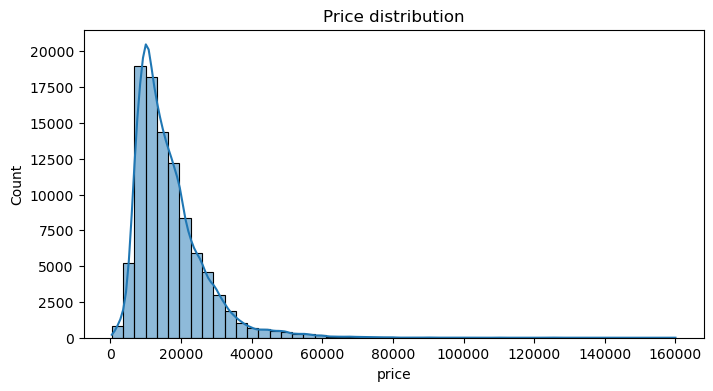

Skew: 2.36236297155461


In [33]:
plt.figure(figsize=(8,4))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Price distribution')
plt.show()
print("Skew:", df['price'].skew())


**Insight:** skewness ≈ 2.36 — strongly right-skewed. Most vehicles cluster in the
lower-to-mid price range, with a long tail of expensive cars pulling the mean well above the
median. A log transform is the standard fix.

In [34]:
df['price_log'] = np.log1p(df['price'])


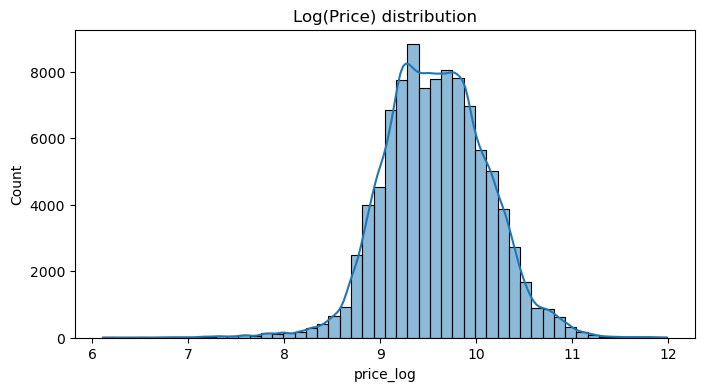

Skew: -0.07545483377572083


In [35]:
plt.figure(figsize=(8,4))
sns.histplot(df['price_log'], bins=50, kde=True)
plt.title('Log(Price) distribution')
plt.show()
print("Skew:", df['price_log'].skew())


**Insight:** skew drops from 2.36 to ≈ −0.08 — close enough to symmetric that `price_log` is the better modeling target. Keeping `price` around too for interpretability (e.g. reporting errors back in £/$/whatever currency this is, not log-units).

## Part 6 — Outlier summary (documentation, not further filtering)

A quick IQR-based scan across the numeric features, mainly to document what's still "unusual"
in the cleaned data rather than to trigger more row-dropping.

In [36]:
def iqr_outlier_summary(df, cols):
    rows = []
    for col in cols:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        count = ((df[col] < lower) | (df[col] > upper)).sum()
        rows.append({
            'column': col,
            'skew': round(df[col].skew(), 2),
            'lower_fence': round(lower, 1),
            'upper_fence': round(upper, 1),
            'outliers': count,
            'pct': round(count/len(df)*100, 2)
        })
    return pd.DataFrame(rows)

iqr_outlier_summary(df, ['price_log', 'mileage', 'tax', 'mpg', 'engineSize', 'age'])


,column,skew,lower_fence,upper_fence,outliers,pct
0,price_log,-0.08,8.1,11.0,1031,1.06
1,mileage,1.78,-29555.6,69733.4,3836,3.93
2,tax,0.04,95.0,175.0,28550,29.24
3,mpg,2.61,23.6,86.4,853,0.87
4,engineSize,1.41,-0.0,3.2,648,0.66
5,age,1.81,2.5,14.5,1732,1.77


**Insight — `tax` is not really an outlier problem.** Its ~29% "outlier" rate is far
higher than every other column, but that's an artifact of IQR fencing rather than a real data
issue: UK vehicle tax is set in discrete government bands tied to emissions, not a smooth
continuous distribution, so a large share of values naturally sit outside a standard IQR fence
even though every one of them is a perfectly valid, real tax band. No action needed here — worth
noting for whoever encodes `tax` as a feature later, since it may behave more like an ordinal
category than a continuous number.

## Part 7 — Final sanity-check visuals

Quick relationship checks before saving. Deeper exploratory analysis (distributions by brand,
interaction effects, etc.) belongs in `02_EDA.ipynb` rather than duplicated here — this is just
enough to confirm the cleaned data behaves the way you'd expect before locking it in.

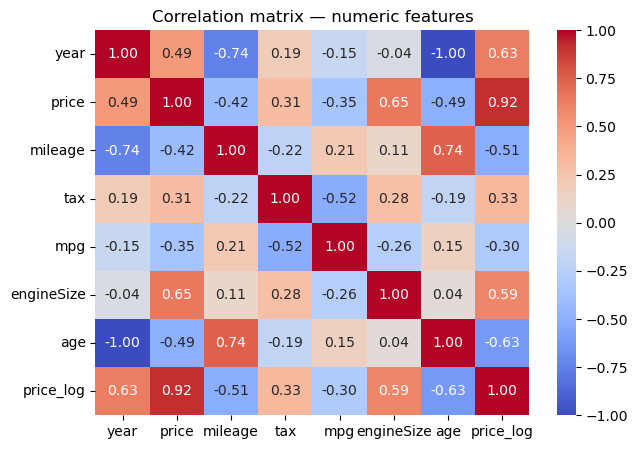

In [37]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
plt.figure(figsize=(7,5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation matrix — numeric features')
plt.show()


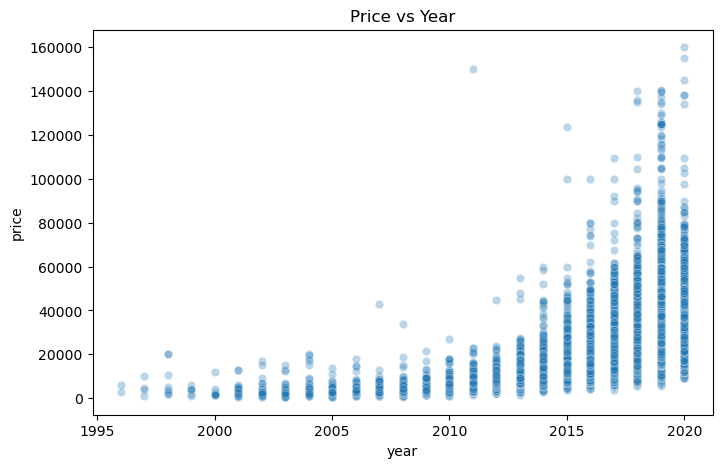

In [38]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='year', y='price', alpha=0.3)
plt.title('Price vs Year')
plt.show()


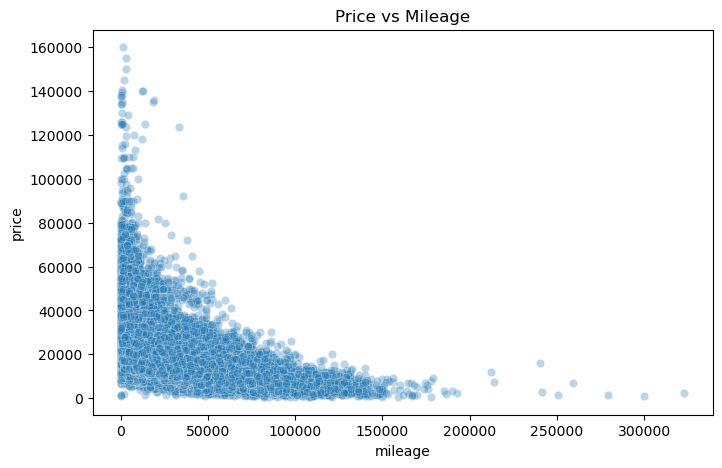

In [39]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='mileage', y='price', alpha=0.3)
plt.title('Price vs Mileage')
plt.show()


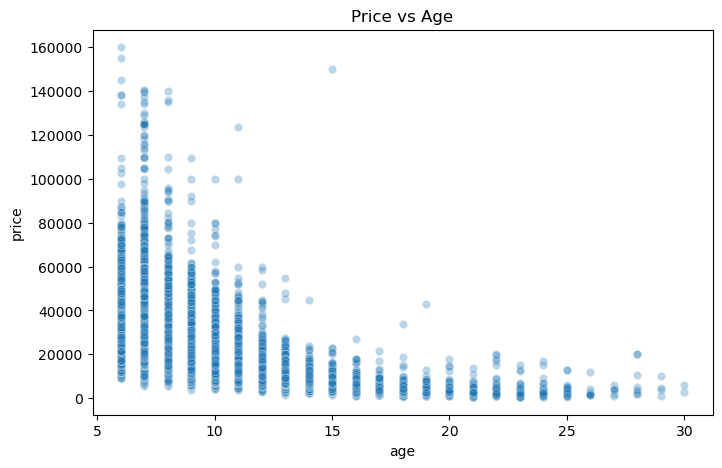

In [40]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='age', y='price', alpha=0.3)
plt.title('Price vs Age')
plt.show()


**Insight:** price generally decreases as age increases, as expected — but newer vehicles
show a much wider spread of prices than older ones. That spread tells you `age` alone won't get
you far in a price model; Make, model, mileage, and engine size are doing a lot of the
remaining explanatory work, which is exactly what `02_EDA.ipynb` should dig into further.

## Part 8 — Save the cleaned dataset

Now that every cleaning decision above has actually run — including the mpg placeholder fix
that used to happen too late — this is the one save point for the notebook.

In [41]:
os.makedirs("../data/processed", exist_ok=True)
df.to_csv("../data/processed/cars_clean.csv", index=False)
print("Saved cleaned data:", df.shape)


Saved cleaned data: (97632, 12)


## Summary

- Structural: dropped the `Unnamed: 0` index column, which was masking 1,475 true duplicate
  rows; deduped; stripped whitespace from `model`.
- `engineSize == 0` (268 rows, almost all non-Electric): treated as missing, imputed via
  Make+model median with a global-median fallback.
- Year: removed 3 rows with impossible years (2060, and two 1970 placeholders); computed `age`
  from `CURRENT_YEAR = 2026` — **worth confirming** this matches your intended semantics, since
  the dataset's actual listings top out at 2020.
- `mpg`: dropped 34 rows below 15 (tested and ruled out a column-swap explanation first), and
  — new in this version — dropped the BMW i3 rows sitting at a placeholder value of 470.8, which
  the previous version identified but never actually removed before saving.
- `price`: confirmed strong right-skew (2.36), added `price_log` (skew ≈ −0.08) as the better
  modeling target.
- `tax`'s high IQR-outlier rate is a banding artifact, not a real data quality issue — flagged
  for whoever encodes it as a feature later.
- Save now happens once, at the end, after all of the above — the previous ordering saved the
  file mid-notebook, before the mpg placeholder issue was even found.

**Open questions for you to confirm, not auto-resolved here:**
1. Is `CURRENT_YEAR = 2026` intentional, or should `age` be computed relative to when this
   dataset was actually collected (~2020, based on its max listing year)?
2. Should the 2 Electric rows with `engineSize == 0` be left at 0 (genuinely no displacement)
   instead of receiving an imputed non-zero value?
